# Fake Job Posting Detection using Machine Learning


## Import Libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load Dataset

In [3]:
df = pd.read_csv("/content/fake_job_postings.csv.zip")

In [4]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


## Exploratory Data Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

## Missing Value Analysis

In [6]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


<Axes: xlabel='fraudulent'>

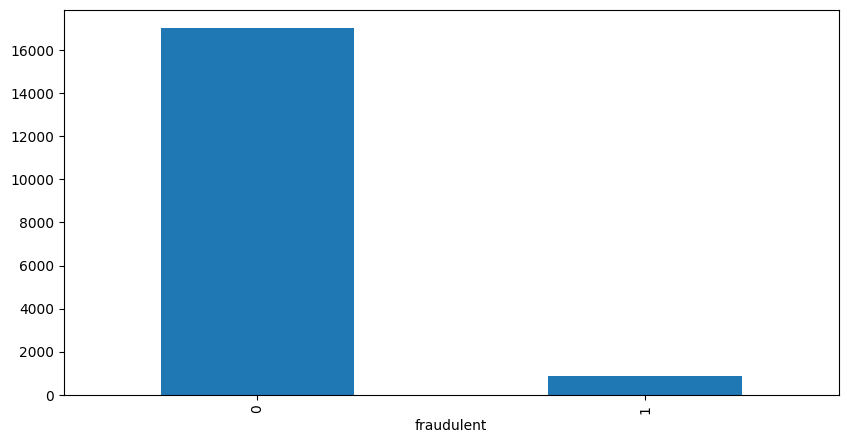

In [7]:
df['fraudulent'].value_counts().plot(kind='bar',figsize=(10,5))

In [8]:
(df["fraudulent"].value_counts(normalize=True) * 100).round(2)

,proportion
fraudulent,
0,95.16
1,4.84


Text(0.5, 1.0, 'Missing Values Heatmap')

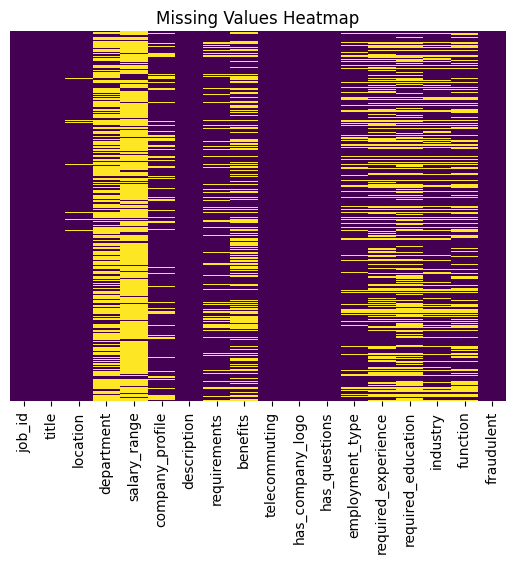

In [9]:
sns.heatmap(df.isnull(),cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")


In [10]:
missing = (df.isnull().sum()/len(df)*100)
missing = missing.sort_values(ascending=False)
missing

,0
salary_range,83.959732
department,64.580537
required_education,45.329978
benefits,40.335570
required_experience,39.429530
function,36.101790
industry,27.421700
employment_type,19.412752
company_profile,18.501119
requirements,15.078300


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'salary_range'),
  Text(1, 0, 'department'),
  Text(2, 0, 'required_education'),
  Text(3, 0, 'benefits'),
  Text(4, 0, 'required_experience'),
  Text(5, 0, 'function'),
  Text(6, 0, 'industry'),
  Text(7, 0, 'employment_type'),
  Text(8, 0, 'company_profile'),
  Text(9, 0, 'requirements'),
  Text(10, 0, 'location'),
  Text(11, 0, 'description'),
  Text(12, 0, 'title'),
  Text(13, 0, 'job_id'),
  Text(14, 0, 'telecommuting'),
  Text(15, 0, 'has_questions'),
  Text(16, 0, 'has_company_logo'),
  Text(17, 0, 'fraudulent')])

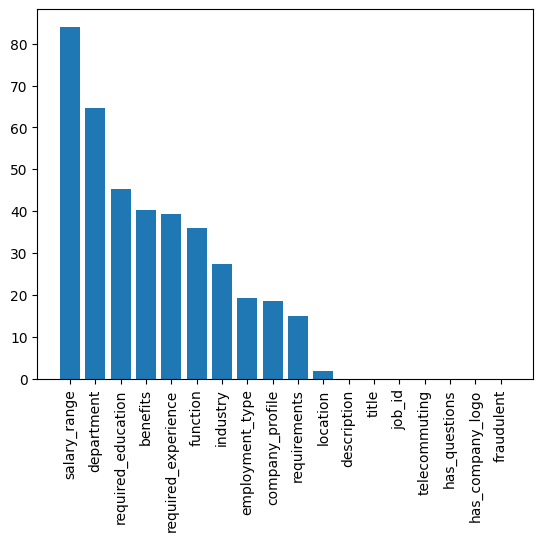

In [11]:
plt.bar(missing.index,missing)
plt.xticks(rotation=90)

## Text Preprocessing

In [13]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]
for cols in text_columns:
  df[cols] = df[cols].fillna(" ")

df[text_columns].isnull().sum()

,0
title,0
company_profile,0
description,0
requirements,0
benefits,0


In [14]:
df["text"] = (
    df["title"].fillna("") + " " +
    df["company_profile"].fillna("") + " " +
    df["description"].fillna("") + " " +
    df["requirements"].fillna("") + " " +
    df["benefits"].fillna("")
)

In [15]:
df[['text','fraudulent']].head()

,text,fraudulent
0,"Marketing Intern We're Food52, and we've creat...",0
1,Customer Service - Cloud Video Production 90 S...,0
2,Commissioning Machinery Assistant (CMA) Valor ...,0
3,Account Executive - Washington DC Our passion ...,0
4,Bill Review Manager SpotSource Solutions LLC i...,0


In [16]:
df["text"] = df["text"].str.lower()

In [17]:
def clean_text(text):
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = df["text"].apply(clean_text)

In [18]:
stop_words = set(stopwords.words("english"))

In [19]:
def remove_stopwords(text):
  words = text.split()
  filtered_word = [word for word in words if word not in stop_words]
  return " ".join(filtered_word)

In [20]:
df["text"] = df["text"].apply(remove_stopwords)

In [21]:
stemmer = PorterStemmer()

In [22]:
def stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

df["text"] = df["text"].apply(stemming)

## Feature Engineering using TF-IDF

In [23]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["text"])
y = df['fraudulent']

## Model Building

In [26]:
X_train , X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14304, 5000)
(3576, 5000)
(14304,)
(3576,)


## Logistic Regression

In [28]:
lr_model = LogisticRegression()
lr_model.fit(X_train,y_train)
y_pred_lr = lr_model.predict(X_test)
print("="*50)
print("Logistic_Regression")
print("="*50)
print(accuracy_score(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))
print(confusion_matrix(y_test,y_pred_lr))

Logistic_Regression
0.9723154362416108
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3395
           1       0.99      0.46      0.63       181

    accuracy                           0.97      3576
   macro avg       0.98      0.73      0.81      3576
weighted avg       0.97      0.97      0.97      3576

[[3394    1]
 [  98   83]]


## Naive Bayes

In [29]:
nb_model = MultinomialNB()
nb_model.fit(X_train,y_train)
y_pred_nb = nb_model.predict(X_test)
acc_nb = accuracy_score(y_test,y_pred_nb)
print("="*50)
print("Naive Bais")
print("="*50)
print(confusion_matrix(y_test,y_pred_nb))
print(classification_report(y_test,y_pred_nb))
print("Accuracy:",acc_nb)


Naive Bais
[[3391    4]
 [ 130   51]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3395
           1       0.93      0.28      0.43       181

    accuracy                           0.96      3576
   macro avg       0.95      0.64      0.71      3576
weighted avg       0.96      0.96      0.95      3576

Accuracy: 0.9625279642058165


## Support Vector Machine

In [30]:
svm_model = LinearSVC()
svm_model.fit(X_train,y_train)
y_pred_svm = svm_model.predict(X_test)
print("="*50)
print("Support Vector Machine")
print("="*50)
print(accuracy_score(y_test,y_pred_svm))
print(confusion_matrix(y_test,y_pred_svm))
print(classification_report(y_test,y_pred_svm))

Support Vector Machine
0.9832214765100671
[[3389    6]
 [  54  127]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       0.95      0.70      0.81       181

    accuracy                           0.98      3576
   macro avg       0.97      0.85      0.90      3576
weighted avg       0.98      0.98      0.98      3576



## Random Forest

In [31]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train,y_train)
y_pred_rf = rf_model.predict(X_test)
print("="*50)
print("Random Forest")
print("="*50)
print(accuracy_score(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Random Forest
0.9790268456375839
[[3395    0]
 [  75  106]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       1.00      0.59      0.74       181

    accuracy                           0.98      3576
   macro avg       0.99      0.79      0.86      3576
weighted avg       0.98      0.98      0.98      3576



## Hyperparameter Tuning

In [40]:
param_grid = {
    "C": [0.01,0.1,1,10,100]
}

grid = GridSearchCV(
    LinearSVC(),
    param_grid,
    cv=5,
    scoring = "f1",
    n_jobs = -1
)

tunned_svm = grid.fit(X_train,y_train)
y_pred_tunned_svm = tunned_svm.predict(X_test)
print("="*50)
print("Tunned Support Vector Machine")
print("="*50)
print(accuracy_score(y_test,y_pred_tunned_svm))
print(confusion_matrix(y_test,y_pred_tunned_svm))
print(classification_report(y_test,y_pred_tunned_svm))


Tunned Support Vector Machine
0.9823825503355704
[[3376   19]
 [  44  137]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3395
           1       0.88      0.76      0.81       181

    accuracy                           0.98      3576
   macro avg       0.93      0.88      0.90      3576
weighted avg       0.98      0.98      0.98      3576



## Model Comparison

In [43]:
results = {
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "Support Vector Machine",
        "Tuned SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test,y_pred_lr),
        acc_nb,
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_svm),
        accuracy_score(y_test,y_pred_tunned_svm)
    ]
}

comparison = pd.DataFrame(results)
comparison.sort_values("Accuracy", ascending=False)

,Model,Accuracy
3,Support Vector Machine,0.983221
4,Tuned SVM,0.982383
2,Random Forest,0.979027
0,Logistic Regression,0.972315
1,Naive Bayes,0.962528


## Prediction System

In [39]:
new_job_post = """
Congratulations!

You have been selected without applying.

Salary ₹2,50,000 per month.

No skills required.

Pay ₹1,999 security deposit today.

Immediate joining.

Only today offer.

Contact on Telegram now.
"""

job_post = clean_text(new_job_post)
job_post = remove_stopwords(job_post)
job_post = stemming(job_post)

job_vector = tfidf.transform([job_post])

prediction = tunned_svm.predict(job_vector)
print(prediction)

if prediction[0] == 1:
  print("The job post is fraudulent.")
else:
  print("The job post is not fraudulent.")

[1]
The job post is fraudulent.
